In [ ]:
import numpy as np
# hzpy - A tool to open .h5 files, which is a common format for storing large amounts of image data.
import h5py
# A helper that shuffles your data and cuts it into two piles (Training and Testing) so you don't have to do it manually.
from sklearn.model_selection import train_test_split

class Dataset_Loader:
    def load_and_split(self):
        # Load original files
        train_dataset = h5py.File('train_catvnoncat.h5', "r")
        test_dataset = h5py.File('test_catvnoncat.h5', "r")

        # At this point, the images are (209, 64, 64, 3). 
        # This means 209 images, each 64x64 pixels, with 3 color channels (Red, Green, Blue).
        
        X_train_orig = np.array(train_dataset["train_set_x"][:]) # (209, 64, 64, 3)
        Y_train_orig = np.array(train_dataset["train_set_y"][:]) # (209,)
        
        X_test_orig = np.array(test_dataset["test_set_x"][:])   # (50, 64, 64, 3)
        Y_test_orig = np.array(test_dataset["test_set_y"][:])   # (50,)

        # The original files aren't exactly 80/20, so we stack them all together into one big pile (X_all) 
        # and then use train_test_split to take exactly 20% for the test set and 80% for training.
        X_all = np.concatenate((X_train_orig, X_test_orig), axis=0)
        Y_all = np.concatenate((Y_train_orig, Y_test_orig), axis=0)

        # 80% Training, 20% Test Split
        X_train, X_test, Y_train, Y_test = train_test_split(
            X_all, Y_all, test_size=0.20, random_state=42
        )

        # Flatten and Normalize
        # Flattening: A computer can't "see" a square image easily in basic Logistic Regression.
        #  We stretch the 64 *64 * 3 image into one long column of 12,288 numbers.
        X_train_flat = X_train.reshape(X_train.shape[0], -1).T / 255.
        X_test_flat = X_test.reshape(X_test.shape[0], -1).T / 255.
        
        # Reshape Y to (1, m)
        # Initially, the labels are just a list. 
        # We turn them into a row vector so they line up perfectly with our image columns during matrix multiplication.
        Y_train = Y_train.reshape((1, Y_train.shape[0]))
        Y_test = Y_test.reshape((1, Y_test.shape[0]))

        # Add Bias Row (Ones)
        X_train_final = np.vstack((np.ones((1, X_train_flat.shape[1])), X_train_flat))
        X_test_final = np.vstack((np.ones((1, X_test_flat.shape[1])), X_test_flat))

        return X_train_final, Y_train, X_test_final, Y_test

loader = Dataset_Loader()
X_train, Y_train, X_test, Y_test = loader.load_and_split()
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (12289, 207), Test shape: (12289, 52)


In [12]:
import matplotlib.pyplot as plt

class LogisticRegression:
    def __init__(self, lr=0.005, epochs=2000):
        self.lr = lr
        self.epochs = epochs
        self.theta = None
        self.train_costs = []
        self.test_costs = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, A, Y):
        m = Y.shape[1]
        # Added epsilon 1e-8 for numerical stability
        loss = -(1/m) * np.sum(Y * np.log(A + 1e-8) + (1 - Y) * np.log(1 - A + 1e-8))
        return loss

    def fit(self, X_train, Y_train, X_test, Y_test):
        n = X_train.shape[0]
        m = X_train.shape[1]
        self.theta = np.zeros((n, 1))

        for i in range(self.epochs):
            # Forward Pass - Train
            Z_train = np.dot(self.theta.T, X_train)
            A_train = self.sigmoid(Z_train)
            train_loss = self.compute_loss(A_train, Y_train)
            
            # Forward Pass - Test (Requirement: Track Test Loss)
            Z_test = np.dot(self.theta.T, X_test)
            A_test = self.sigmoid(Z_test)
            test_loss = self.compute_loss(A_test, Y_test)
            
            # Record costs for plotting
            self.train_costs.append(train_loss)
            self.test_costs.append(test_loss)

            # Gradient Descent
            dtheta = (1/m) * np.dot(X_train, (A_train - Y_train).T)
            self.theta = self.theta - self.lr * dtheta

            if i % 500 == 0:
                print(f"Iteration {i}: Train Loss {train_loss:.4f} | Test Loss {test_loss:.4f}")

    def predict(self, X):
        A = self.sigmoid(np.dot(self.theta.T, X))
        return (A > 0.5).astype(int)

    def confusion_matrix(self, X, Y):
        pred = self.predict(X)
        TP = np.sum((pred == 1) & (Y == 1))
        TN = np.sum((pred == 0) & (Y == 0))
        FP = np.sum((pred == 1) & (Y == 0))
        FN = np.sum((pred == 0) & (Y == 1))
        return TP, TN, FP, FN

In [13]:
# Initialize and Train
model = LogisticRegression(lr=0.005, epochs=2500)
model.fit(X_train, Y_train, X_test, Y_test)

# Report for Test Set (Requirement: Report TP, TN, FP, FN)
TP, TN, FP, FN = model.confusion_matrix(X_test, Y_test)

print("\n" + "="*30)
print("FINAL TEST SET REPORT")
print("="*30)
print(f"True Positives (TP):  {TP}")
print(f"True Negatives (TN):  {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")

accuracy = (TP + TN) / (TP + TN + FP + FN) * 100
print(f"Test Accuracy: {accuracy:.2f}%")
print("="*30)

Iteration 0: Train Loss 0.6931 | Test Loss 0.6931
Iteration 500: Train Loss 0.2657 | Test Loss 0.7750
Iteration 1000: Train Loss 0.1842 | Test Loss 0.8753
Iteration 1500: Train Loss 0.1414 | Test Loss 0.9471
Iteration 2000: Train Loss 0.1144 | Test Loss 1.0028

FINAL TEST SET REPORT
True Positives (TP):  11
True Negatives (TN):  18
False Positives (FP): 13
False Negatives (FN): 10
Test Accuracy: 55.77%


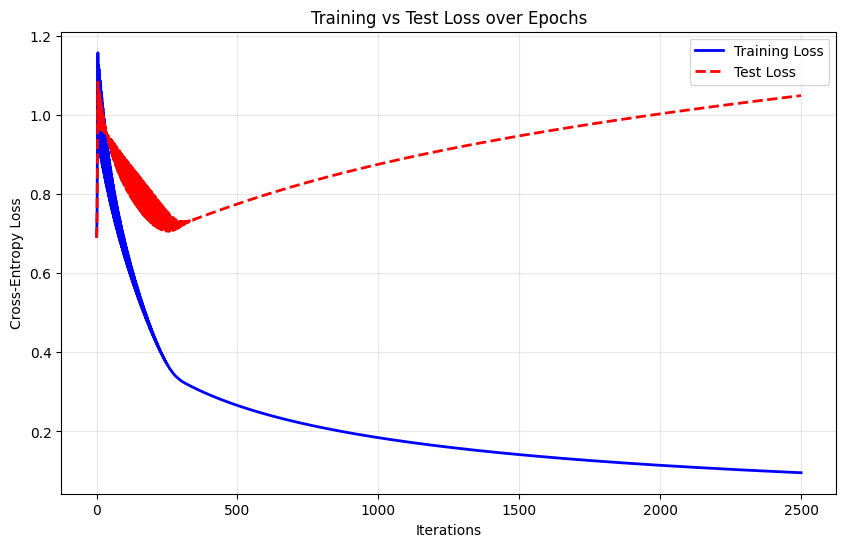

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(model.train_costs, label='Training Loss', color='blue', linewidth=2)
plt.plot(model.test_costs, label='Test Loss', color='red', linestyle='--', linewidth=2)
plt.title('Training vs Test Loss over Epochs')
plt.xlabel('Iterations')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()